**libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

**Load Dataset**

In [5]:
df = pd.read_csv('/content/spam.csv', encoding='latin-1')
df = df[['v1','v2']]  # Keep only label and message
df.columns = ['label','message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


**Explore Dataset**

(5572, 2)
label
ham     4825
spam     747
Name: count, dtype: int64


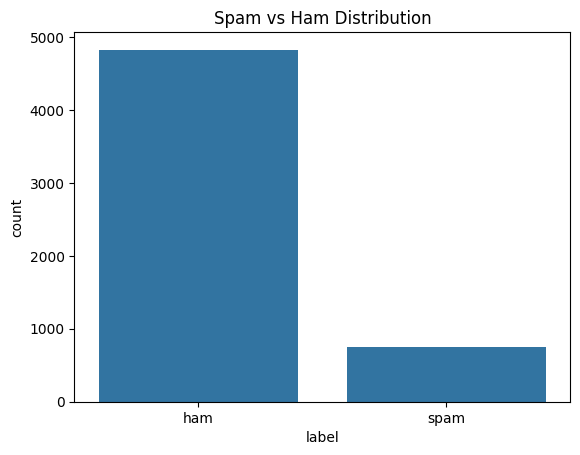

In [6]:
print(df.shape)
print(df['label'].value_counts())

sns.countplot(x='label', data=df)
plt.title("Spam vs Ham Distribution")
plt.show()

**Data Cleaning & Preprocessing**


Convert labels to numeric

In [7]:
df['label_num'] = df['label'].map({'ham':0,'spam':1})

**Text cleaning function**

In [8]:
def clean_text(text):
    text = text.lower()  # lowercase
    text = "".join([char for char in text if char not in string.punctuation])  # remove punctuation
    words = text.split()
    words = [word for word in words if word not in stopwords.words('english')]  # remove stopwords
    return " ".join(words)

df['clean_message'] = df['message'].apply(clean_text)
df.head()

,label,message,label_num,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",0,go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,0,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,free entry 2 wkly comp win fa cup final tkts 2...
3,ham,U dun say so early hor... U c already then say...,0,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,nah dont think goes usf lives around though


**Convert Text to Numbers (TF-IDF)**

In [10]:
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['clean_message'])
y = df['label_num']

**Train-Test Split**

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Train Naive Bayes Model**

In [12]:
nb = MultinomialNB()
nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)


**Train Logistic Regression Model**

In [13]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

**Evaluate Models**


Naive Bayes

In [14]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(confusion_matrix(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.9659192825112107
[[965   0]
 [ 38 112]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.75      0.85       150

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115



**Logistic Regression**

In [15]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(confusion_matrix(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.9426008968609866
[[961   4]
 [ 60  90]]
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       965
           1       0.96      0.60      0.74       150

    accuracy                           0.94      1115
   macro avg       0.95      0.80      0.85      1115
weighted avg       0.94      0.94      0.94      1115



**Example Predictions**

In [16]:
sample_messages = ["Congratulations! You won a free iPhone",
                   "Hey, are we meeting today?"]

sample_clean = [clean_text(msg) for msg in sample_messages]
sample_tfidf = tfidf.transform(sample_clean)

predictions = nb.predict(sample_tfidf)
for msg, pred in zip(sample_messages, predictions):
    print(msg, "->", "Spam" if pred==1 else "Ham")

Congratulations! You won a free iPhone -> Ham
Hey, are we meeting today? -> Ham


**Visualize Confusion Matrix**

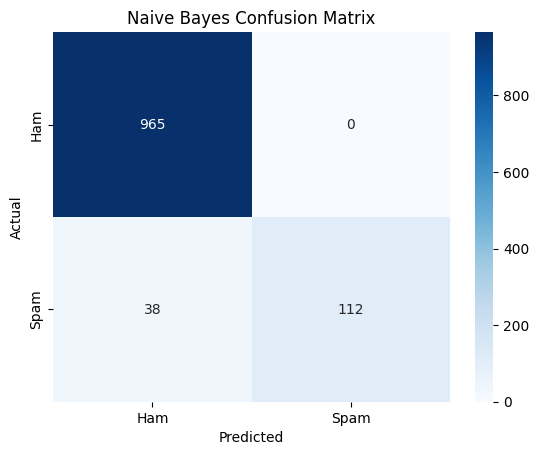

In [17]:
cm = confusion_matrix(y_test, nb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")
plt.show()